In [3]:
import pandas as pd
import matplotlib.pyplot as plt

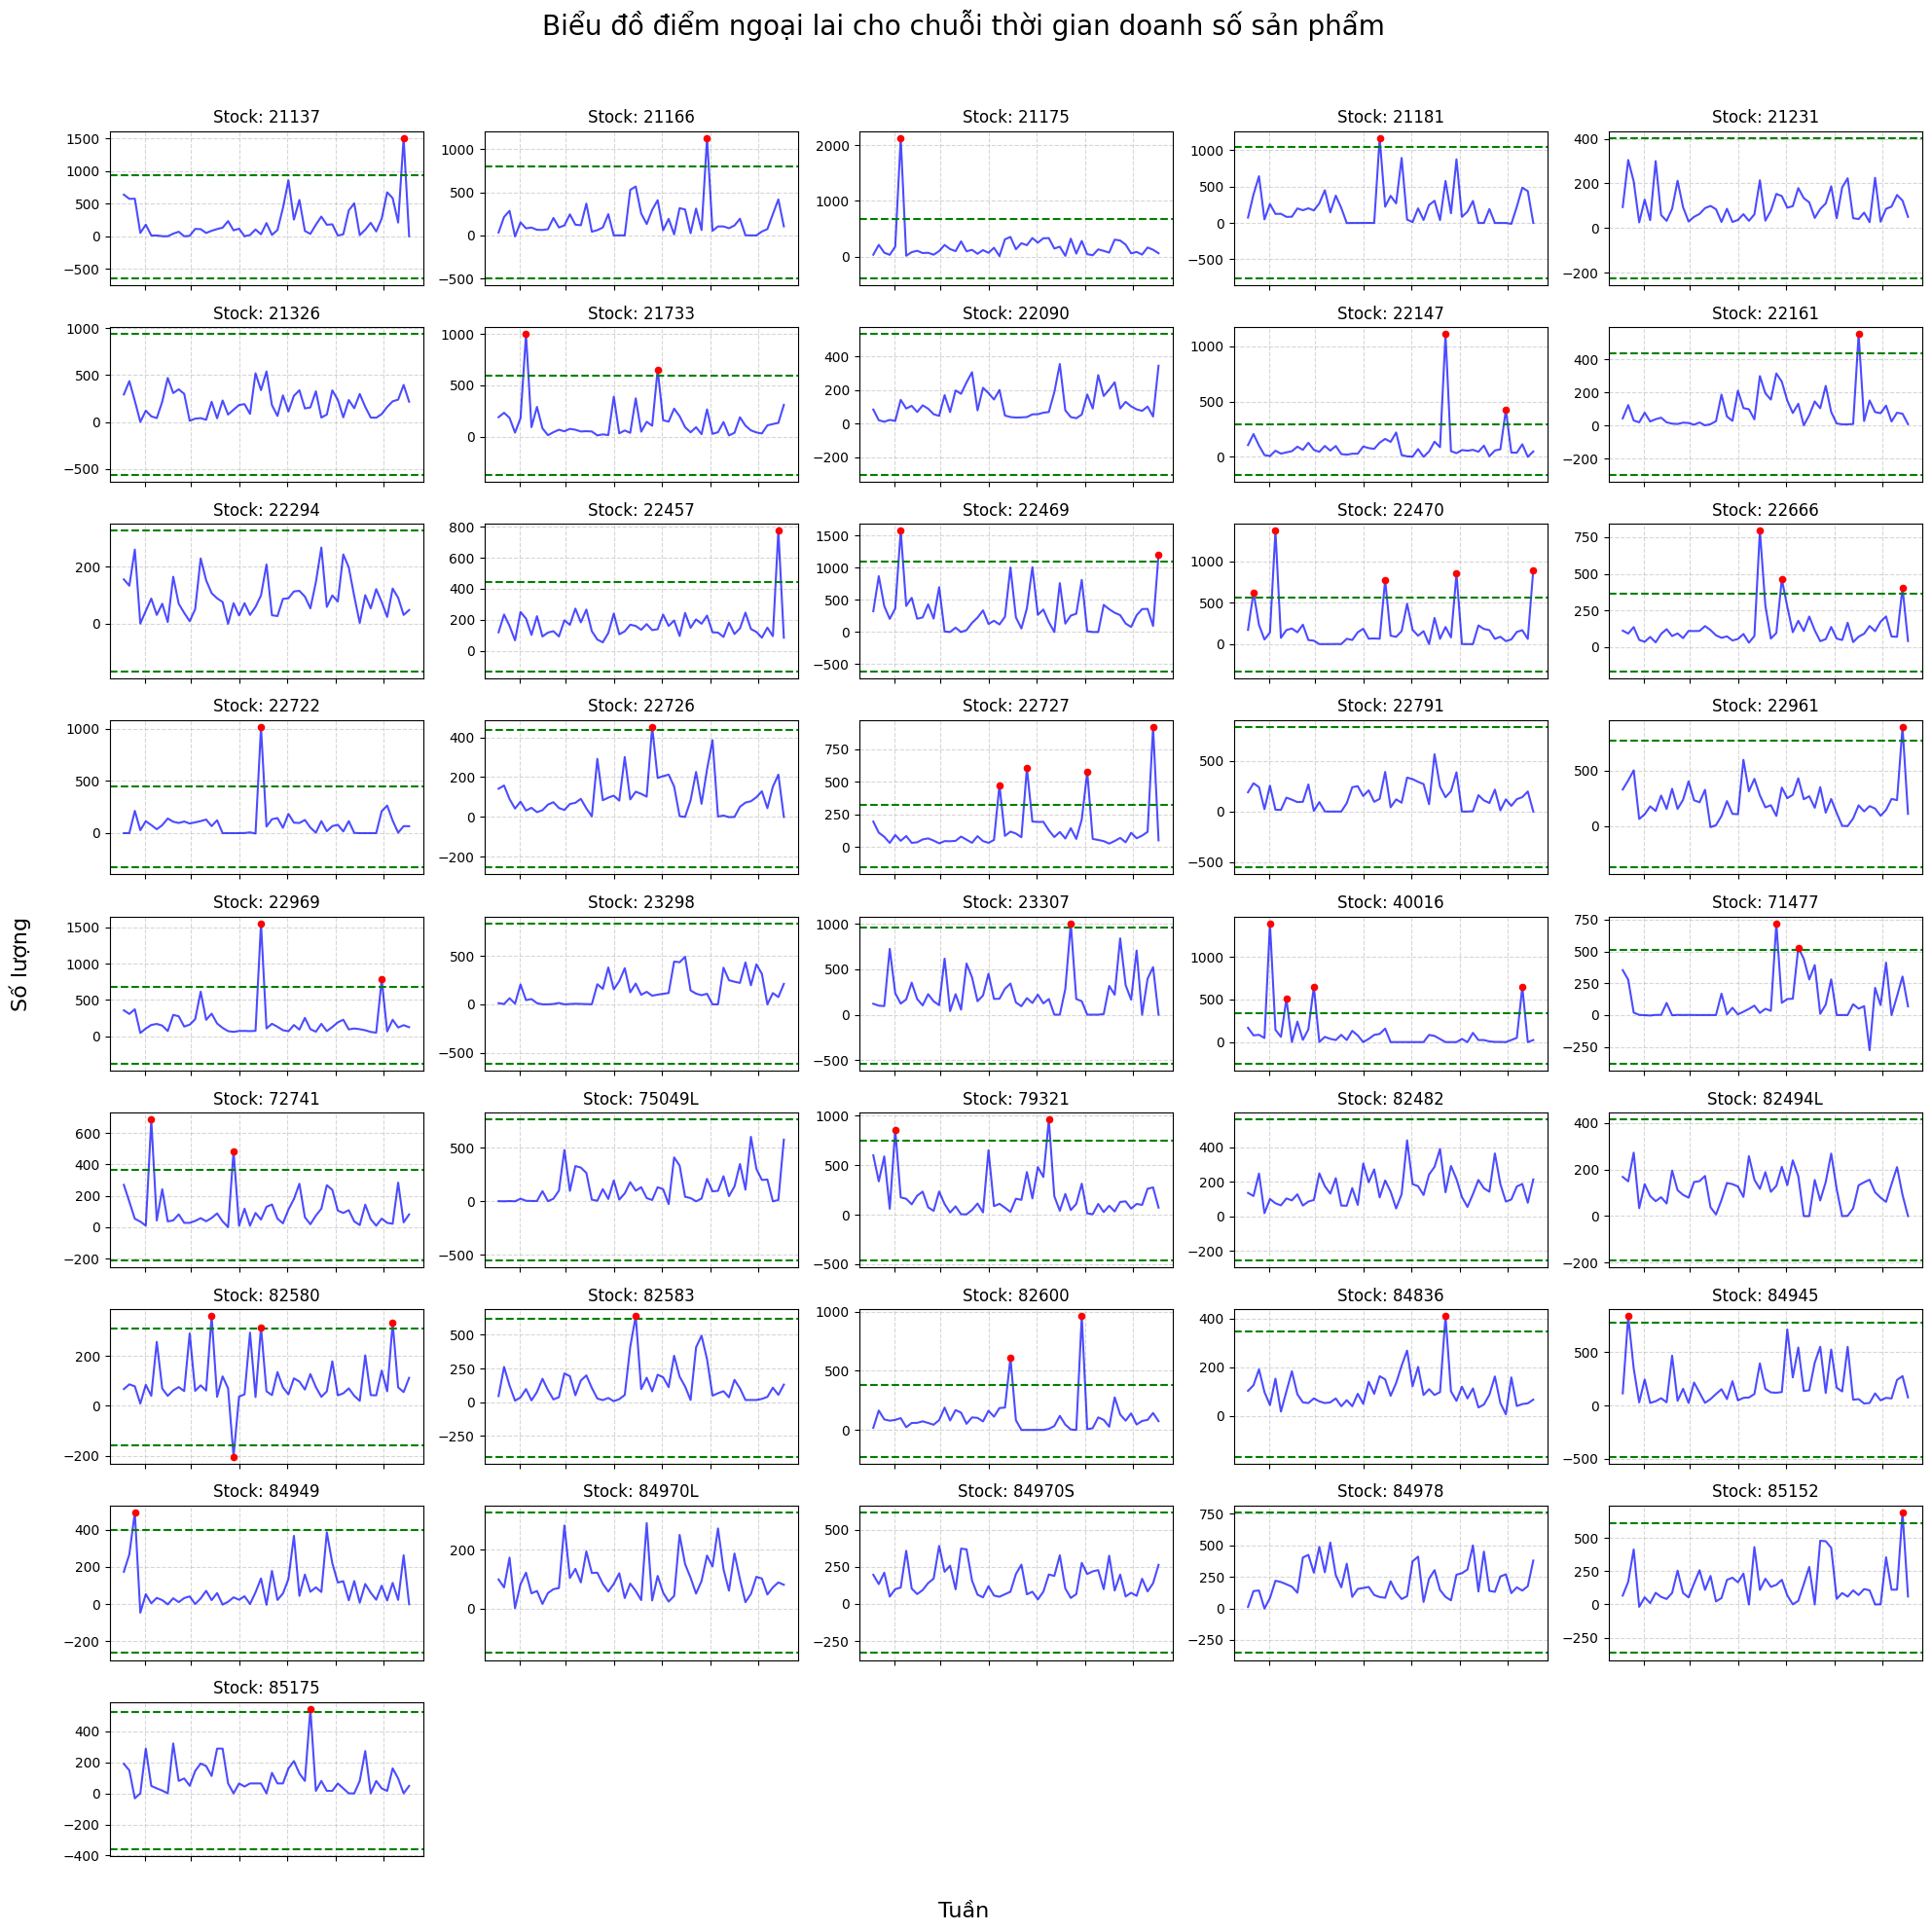

In [4]:
df = pd.read_csv("../dataset/quantity_weekly_decor_cooked.csv")
df_melted = df.melt(id_vars=['StockCode'], var_name='Week', value_name='Quantity')
weeks = [f'{i}' for i in range(1, 54)]
dates = pd.date_range(start='2010-12-01', periods=53, freq='W')
date_map = dict(zip(weeks, dates))

df_melted['Date'] = df_melted['Week'].map(date_map)
ts_data = df_melted.pivot(index='Date', columns='StockCode', values='Quantity')

fig, axes = plt.subplots(nrows=9, ncols=5, figsize=(20, 20), sharex=True)
axes = axes.flatten()

for i, stock_code in enumerate(ts_data.columns):
    if i < 45:
        series = ts_data[stock_code]
        
        Q1 = series.quantile(0.25)
        Q3 = series.quantile(0.75)
        IQR = Q3 - Q1
        upper_bound = Q3 + 3.0 * IQR
        lower_bound = Q1 - 3.0 * IQR
        
        outliers = series[(series > upper_bound) | (series < lower_bound)]

        axes[i].plot(series.index, series.values, color='blue', linewidth=1.5, alpha=0.7, label='Data')
        if not outliers.empty:
            axes[i].scatter(outliers.index, outliers.values, color='red', s=20, zorder=5, label='Outlier')

        axes[i].axhline(upper_bound, color='green', linestyle='--', label='Ngưỡng trên (IQR)')
        axes[i].axhline(lower_bound, color='green', linestyle='--', label='Ngưỡng dưới (IQR)')
            
        axes[i].set_title(f"Stock: {stock_code}")
        axes[i].grid(True, linestyle='--', alpha=0.5)
        axes[i].tick_params(axis='both', which='major')
        axes[i].tick_params(axis='x', which='both', labelbottom=False)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

fig.text(0.5, 0.01, 'Tuần', ha='center', fontsize=16)
fig.text(0.01, 0.5, 'Số lượng', va='center', rotation='vertical', fontsize=16)

plt.suptitle("Biểu đồ điểm ngoại lai cho chuỗi thời gian doanh số sản phẩm", fontsize=20, y=0.99)
plt.tight_layout(rect=[0.03, 0.03, 1, 0.97])
plt.show()